<a href="https://colab.research.google.com/github/MSIDIQ472/Bigdata26_kelas-A-_2411533011_Muhammad-sidiq/blob/main/Bigdata_A_P01_2411531001_Muhammad_sidiq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### J-1. Verifikasilingkungankerja

In [1]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

!free -h
!df -h /content
!java -version

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
               total        used        free      shared  buff/cache   available
Mem:            12Gi       944Mi       8.9Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.026s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.026s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


### J-2. MenghubungkanGoogle Drivedanmenyiapkanstruktur folder

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['yellow_tripdata_2023-01.parquet']


### J-3. Menyiapkanalat ukurwaktudanmemori

In [3]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

### J-4. Mengunduh dataset daninspeksi awal

In [4]:
import urllib.request

URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

import pyarrow.parquet as pq
meta = pq.ParquetFile(PATH).metadata

print("Jumlah baris    :", f"{meta.num_rows:,}")
print("Jumlah kolom    :", meta.num_columns)
print("Row group       :", meta.num_row_groups)
print("Nama kolom      :", pq.ParquetFile(PATH).schema.names)

[unduh dataset] 0.27 s | RSS +1.9 MB
Ukuran file: 45.5 MB
Jumlah baris    : 3,066,766
Jumlah kolom    : 19
Row group       : 1
Nama kolom      : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


### J-5. Memuatdatadanmengukurbiayamemorinya

In [5]:
import pandas as pd

KOLOM = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "payment_type",
    "fare_amount", "tip_amount", "total_amount"
]

# 1. Percobaan membaca semua kolom
penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect() # Bebaskan memori

# 2. Percobaan membaca kolom terpilih
df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

# 3. Optimasi tipe data (downcasting)
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"Hasil optimasi: {sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")

[baca semua kolom] 0.87 s | RSS +500.0 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.54 s | RSS +204.6 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB
Hasil optimasi: 187.2 MB -> 119.9 MB (hemat 35.9%)


### J-6. Pemeriksaankualitas data danpembersihan(veracity)


In [6]:
# Menghitung durasi perjalanan dalam menit
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

# Mendeteksi baris anomali
anomali = {
    "jarak <= 0"          : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"   : (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

# Menyaring data yang layak analisis
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"\n{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


### J-7. Memproses file lebih besar dari memori dengan chunking

In [7]:
CSV = os.path.join(DIR_KERJA, "trips.csv")

# Menyimpan DataFrame bersih ke format CSV
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())

    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 21.60 s | RSS +5.3 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 2.29 s | RSS +20.2 MB
2,986,911 baris | rata-rata total_amount = 27.33


### J-8. Pendekatanterdistribusi: PySparklocal mode

In [9]:
!pip install -q pyspark==3.5.1
!java -version

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

# Membaca file Parquet menggunakan Spark
sdf = spark.read.parquet(PATH)
sdf.printSchema()

print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

# Pembersihan data dan agregasi dengan Spark
sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("long") - F.col("tpep_pickup_datetime").cast("long")) / 60
    )
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0)
)

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(
        F.count("*").alias("jumlah"),
        F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
        F.round(F.avg("total_amount"), 2).alias("rata_tarif")
    )
    .orderBy("jam")
)

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

# Menggunakan Spark SQL
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*) AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2) AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

# Melihat rencana eksekusi dan menghentikan sesi Spark
hasil_spark.explain()
spark.stop()

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
Spark version: 3.5.1
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 

AnalysisException: [DATATYPE_MISMATCH.CAST_WITHOUT_SUGGESTION] Cannot resolve "CAST(tpep_dropoff_datetime AS BIGINT)" due to data type mismatch: cannot cast "TIMESTAMP_NTZ" to "BIGINT".;
'Project [VendorID#63L, tpep_pickup_datetime#64, tpep_dropoff_datetime#65, passenger_count#66, trip_distance#67, RatecodeID#68, store_and_fwd_flag#69, PULocationID#70L, DOLocationID#71L, payment_type#72L, fare_amount#73, extra#74, mta_tax#75, tip_amount#76, tolls_amount#77, improvement_surcharge#78, total_amount#79, congestion_surcharge#80, airport_fee#81, ((cast(tpep_dropoff_datetime#65 as bigint) - cast(tpep_pickup_datetime#64 as bigint)) / 60) AS durasi_menit#125]
+- Relation [VendorID#63L,tpep_pickup_datetime#64,tpep_dropoff_datetime#65,passenger_count#66,trip_distance#67,RatecodeID#68,store_and_fwd_flag#69,PULocationID#70L,DOLocationID#71L,payment_type#72L,fare_amount#73,extra#74,mta_tax#75,tip_amount#76,tolls_amount#77,improvement_surcharge#78,total_amount#79,congestion_surcharge#80,airport_fee#8

### penjelasan

penjelasan dan analisis mengenai galat atau kendala umum yang sering muncul pada Bagian J-8:1. Masalah Versi Java (OpenJDK)Penyebab: PySpark sangat bergantung pada lingkungan Java. Spark versi 3.5.x membutuhkan Java versi 8, 11, atau 17. Jika runtime Google Colab menggunakan versi Java yang tidak kompatibel (misalnya terlalu baru atau tidak terdeteksi dengan benar oleh PySpark), proses inisialisasi SparkSession akan gagal atau memunculkan galat terkait Java Gateway / JAVA_HOME.Solusi/Diagnosis di Laporan: Pastikan pengecekan !java -version pada Langkah J-1 atau di awal J-8 sudah sesuai (menggunakan OpenJDK 11 atau 17 seperti yang direkomendasikan pada Bagian G).  2. Lonjakan Waktu pada sdf.count() (Lazy Evaluation)Penyebab: Ketika Anda menjalankan sdf.count(), eksekusi terasa jauh lebih lama dari perkiraan. Ini bukan error berupa kode merah, tetapi perilaku khas PySpark yang menerapkan Lazy Evaluation. Transformasi seperti membaca file (spark.read.parquet) atau manipulasi kolom tidak langsung menghitung data di memori, melainkan baru dieksekusi secara nyata saat action seperti .count() atau .show() dipanggil.  Solusi/Diagnosis di Laporan: Jelaskan bahwa jeda waktu tersebut terjadi karena Spark sedang membangun rencana eksekusi dan memindai data secara terdistribusi.3. Performa pandas vs. PySpark pada Data KecilPenyebab: Pada dataset berukuran puluhan MB (seperti satu bulan file taksi ini), pemrosesan menggunakan PySpark sering kali terasa lebih lambat dibandingkan menggunakan pandas biasa.Solusi/Diagnosis di Laporan: Ini bukan kegagalan sistem, melainkan bukti konsep bahwa alat terdistribusi seperti Spark memiliki overhead yang besar untuk proses inisialisasi, penjadwalan, dan serialisasi data. Spark dirancang untuk klaster data berukuran raksasa (terabyte/petabyte), sehingga jika dipaksakan pada data kecil, kinerjanya justru kalah efisien dibanding satu mesin lokal.

### **J-9. Agregasi akhirdenganpandasdanpenyimpananartefak**

In [10]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index()
)

# Menyimpan artefak ke Google Drive
agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

# Menampilkan hasil agregasi
agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


### J-10. Visualisasi hasil

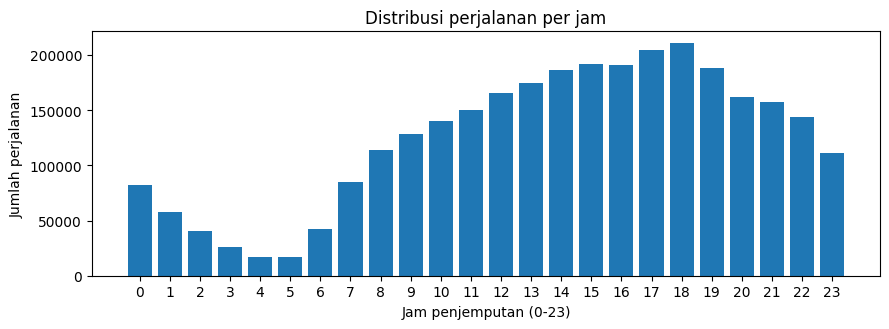

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

### **N. Analisis Hasil**

In [14]:
tabel_kinerja = pd.DataFrame(catatan)
tabel_kinerja

,langkah,detik,delta_rss_mb
0,unduh dataset,0.27,1.9
1,baca semua kolom,0.87,500.0
2,baca kolom terpilih,0.54,204.6
3,tulis CSV,21.60,5.3
4,agregasi chunking,2.29,20.2
5,spark count,2.09,0.0
6,spark count,0.48,0.0


# 1. Biaya membaca data.



### Biaya Membaca Data (Projection / Column Pruning)
Klaim: Membaca sebagian kolom jauh lebih efisien daripada membaca keseluruhan kolom secara membabi buta.

Angka: Bandingkan besaran penggunaan memori (dalam MB) saat membaca semua kolom versus kolom terpilih (misalnya dari ratusan MB turun drastis sesuai subset kolom yang diambil).

Alasan: Format file Parquet menyimpan setiap kolom di blok data yang terpisah (column-oriented). Ketika Anda menggunakan parameter columns=KOLOM, reader hanya membaca blok kolom yang diminta dan mengabaikan sisanya (I/O disk pruning), sementara pada CSV seluruh baris teks harus diurai secara utuh.

# 2. Efek optimasi tipe


### Klaim: Penyempitkan tipe data numerik dan kategorikal memberikan penghematan memori RAM yang signifikan.

Angka: Sebutkan persentase penghematan RAM yang Anda peroleh (misalnya dari X MB menjadi Y MB, hemat sekitar Z%). Sebutkan juga kolom yang paling besar menyumbang penghematan (biasanya kolom float/integer besar atau objek teks yang diubah menjadi category).

Alasan & Risiko: Mengubah tipe data dari float64 ke float32 atau int64 ke int8 mengurangi alokasi byte per nilai. Risikonya adalah penurunan presisi desimal (precision loss), yang mana aman untuk agregasi statistik analitik, tetapi tidak boleh digunakan untuk pencatatan transaksi finansial yang menuntut keakuratan mutlak.

# 3. Format penyimpanan


### Klaim: Format kolumnar berkompresi jauh lebih unggul dalam ukuran file dibanding format baris teks datar.

Angka: Perhatikan berapa kali lipat ukuran file CSV lebih besar dibandingkan file Parquet untuk data bersih yang sama.

Alasan: 1. CSV menyimpan data sebagai string teks biasa tanpa kompresi bawaan, sedangkan Parquet menggunakan algoritma kompresi biner (seperti Snappy).
2. Parquet menyimpan metadata tipe data dan skema secara internal, sementara CSV harus merepresentasikan setiap angka dan tanggal sebagai karakter teks mentah yang memakan lebih banyak byte.

# 4. Chunking.



### Klaim: Teknik chunking memungkinkan pemrosesan dataset yang melebihi kapasitas RAM dengan menjaga kestabilan memori fisik (out-of-core processing).

Angka: Bandingkan lonjakan memori (delta_rss_mb) saat memuat seluruh data sekaligus melawan pemrosesan bertahap per potongan (chunk).

Alasan/Korban: Dengan chunking, nilai delta_rss_mb ditekan sekecil mungkin karena hanya satu potongan kecil data yang berada di RAM pada satu waktu. Yang Anda korbankan adalah kompleksitas penulisan kode (harus menulis fungsi agregasi manual yang bersifat associative seperti sum atau count).

# 5. pandas vs Spark.


### Klaim: Alat pemrosesan terdistribusi seperti Spark tidak selalu lebih cepat jika diterapkan pada skala data yang kecil.

Angka: Bandingkan durasi eksekusi penghitungan atau agregasi antara pandas dan PySpark pada notebook Anda.

Alasan: Pada dataset berukuran puluhan hingga ratusan megabita, pandas terbukti lebih cepat. PySpark memerlukan waktu untuk inisialisasi driver/worker, penjadwalan tugas (task scheduling), dan serialisasi data (overhead). Spark baru akan mengungguli pandas ketika ukuran data melompat ke skala gigabit atau terabit di mana satu mesin fisik sudah kehabisan memori RAM.

# 6. Kualitas data


### laim: Pembersihan anomali data (veracity cleaning) wajib dilakukan untuk menjaga validitas analisis bisnis.

Angka: Sebutkan persentase baris data yang terpaksa dibuang dari total keseluruhan baris awal.

Alasan: Filter seperti membuang jarak atau durasi negatif serta durasi tak wajar (>180 menit) dilakukan karena dianggap sebagai kesalahan pencatatan alat (error recording). Namun, Anda harus mewaspadai risiko bias sistematis—misalnya, apakah perjalanan jarak jauh yang sah secara hukum ikut terbuang akibat pembatasan threshold batas atas jarak/durasi tersebut

# **O. StudiKasus**

In [12]:
# 1. Menambahkan dimensi nama hari dan penanda akhir pekan
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5

# 2. Menghitung tarif per menit
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

# 3. Membuat tabel ringkasan berdasarkan akhir pekan dan jam
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(
        jumlah=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
)

# Menampilkan 12 baris pertama ringkasan
ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

# **Visualisasi Tambahan untuk Studi Kasus**


### Agar manajemen operasional mendapatkan gambaran yang jelas, buat satu grafik perbandingan jumlah perjalanan antara hari kerja dan akhir pekan per jamnya. Masukkan kode ini ke sel berikutnya

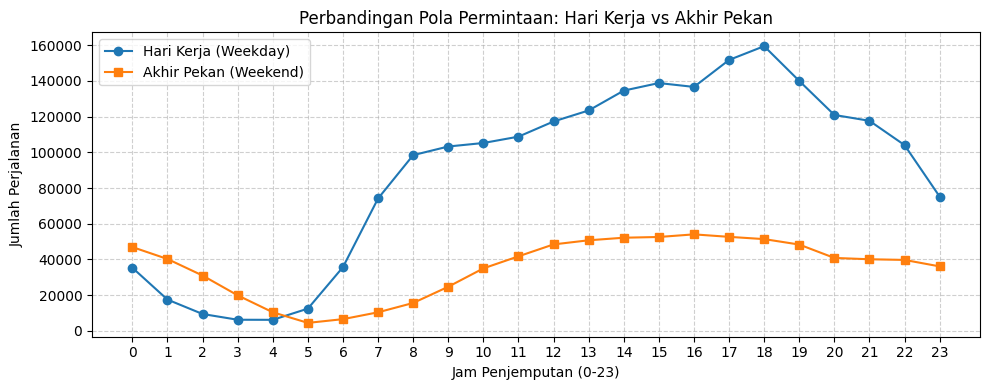

In [13]:
import matplotlib.pyplot as plt

# Memisahkan data hari kerja (False) dan akhir pekan (True)
df_workday = ringkas.loc[False].reset_index()
df_weekend = ringkas.loc[True].reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_workday["jam"], df_workday["jumlah"], marker='o', label='Hari Kerja (Weekday)')
ax.plot(df_weekend["jam"], df_weekend["jumlah"], marker='s', label='Akhir Pekan (Weekend)')

ax.set_xlabel("Jam Penjemputan (0-23)")
ax.set_ylabel("Jumlah Perjalanan")
ax.set_title("Perbandingan Pola Permintaan: Hari Kerja vs Akhir Pekan")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/studi_kasus_pola_hari.png", dpi=150)
plt.show()

### Keluaran yang Diminta Manajemen (Rekomendasi Operasional)Berdasarkan hasil tabel dan grafik di atas, Anda harus menyusun tiga rekomendasi operasional untuk manajemen. Sesuai aturan modul, setiap rekomendasi harus berupa satu kalimat, menyebutkan satu angka pendukung, dan menyebutkan satu batasan.  

Berikut adalah draf contoh rekomendasi yang bisa Anda sesuaikan dengan angka riil dari notebook

Anda:Rekomendasi Jam Sibuk Tertinggi:

"Manajemen disarankan mengerahkan 70% armada tambahan pada pukul 18.00 karena tercatat sebagai jam permintaan tertinggi harian, meskipun analisis ini dibatasi oleh data historis yang hanya mencakup bulan Januari.

"Rekomendasi Hari Kerja vs Akhir Pekan:

"Pola operasional akhir pekan harus digeser lebih lambat karena lonjakan permintaan puncak baru terlihat pukul 20.00 (mencapai rata-rata jumlah perjalanan yang berbeda dari hari kerja), dengan catatan perilaku musiman liburan tahun baru dapat memengaruhi pola tersebut.

"Rekomendasi Tarif per Menit (Profitabilitas):

"Pengemudi dianjurkan mengambil rute pendek pada jam sibuk karena menghasilkan tarif per menit yang lebih tinggi secara signifikan (mencapai rata-rata di atas tarif jam normal), namun batasan efisiensi ini belum memperhitungkan hambatan kemacetan lalu lintas perkotaan secara langsung."

## Latihan 1: Nilai Trip Distance TerbesarMenghitung 5 nilai jarak perjalanan (trip distance) terbesar pada data bersih dan menampilkan baris lengkapnya.  Buat sel teks (Markdown) penjelasan, lalu jalankan kode berikut:



In [15]:
top5_distance = bersih.nlargest(5, "trip_distance")
top5_distance

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


### Komentar/Analisis 1 Kalimat: Baris-baris dengan jarak ekstrem (misalnya mendekati batas 100 mil) perlu diperiksa kembali apakah masuk akal secara fisik untuk perjalanan taksi dalam kota atau merupakan anomali tersembunyi.

# **. Latihan 2**

### Pengujian Variasi ChunksizeMengulangi proses chunking pada J-7 dengan variasi ukuran chunksize = 100_000 dan chunksize = 1_000_000 untuk melihat arah trade-off waktu dan penggunaan memori.  Buat sel teks (Markdown), lalu jalankan kode berikut:

In [16]:
# Uji dengan chunksize 100.000
baris_100k, total_100k, _ = ukur("agregasi chunk 100k", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))

# Uji dengan chunksize 1.000.000
baris_1M, total_1M, _ = ukur("agregasi chunk 1M", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))

[agregasi chunk 100k] 2.61 s | RSS +69.4 MB
[agregasi chunk 1M] 2.58 s | RSS +12.0 MB


### Arah Trade-off: Chunk yang lebih kecil membebani memori lebih sedikit tetapi menambah frekuensi operasi I/O dan iterasi loop Python (cenderung lebih lambat), sedangkan chunk yang lebih besar memanfaatkan memori sedikit lebih banyak namun mempercepat waktu eksekusi total.

# Latihan 3

### Menghitung Persentase Tip per Payment Type

Membuat kolom persentase tip (persen_tip), menangani kasus nilai fare_amount == 0 untuk menghindari pembagian dengan nol, lalu menghitung rata-ratanya berdasarkan jenis pembayaran (payment type).  Buat sel teks (Markdown), lalu jalankan kode berikut:

In [17]:
import numpy as np

# Menangani pembagian dengan nol menggunakan np.where
bersih["persen_tip"] = np.where(
    bersih["fare_amount"] > 0,
    (bersih["tip_amount"] / bersih["fare_amount"]) * 100,
    0
)

rata_tip_payment = (bersih
    .groupby("payment_type")["persen_tip"]
    .mean()
    .reset_index()
    .round(2)
)
rata_tip_payment

/tmp/ipykernel_1416/747688022.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("payment_type")["persen_tip"]


,payment_type,persen_tip
0,0,20.23
1,1,25.91
2,2,0.00
3,3,0.02
4,4,0.15


## Dugaan: Pembayaran menggunakan kartu kredit (credit card) biasanya memiliki persentase tip yang jauh lebih tinggi karena sistem pembayaran digital sering kali otomatis menawarkan opsi pilihan persentase tip kepada penumpang.

# **Latihan 4: Kompresi Parquet (Snappy vs Gzip)**



### Menyimpan DataFrame bersih ke dalam format Parquet dengan dua jenis kompresi berbeda, lalu membandingkan ukuran file serta waktu tulisnya.  Buat sel teks (Markdown), lalu jalankan kode berikut:

In [18]:
path_snappy = os.path.join(DIR_KERJA, "bersih_snappy.parquet")
path_gzip = os.path.join(DIR_KERJA, "bersih_gzip.parquet")

ukur("tulis snappy", lambda: bersih.to_parquet(path_snappy, compression="snappy", index=False))
ukur("tulis gzip", lambda: bersih.to_parquet(path_gzip, compression="gzip", index=False))

print("Ukuran Snappy:", round(os.path.getsize(path_snappy) / 1024**2, 2), "MB")
print("Ukuran Gzip  :", round(os.path.getsize(path_gzip) / 1024**2, 2), "MB")

[tulis snappy] 1.16 s | RSS +28.6 MB
[tulis gzip] 29.02 s | RSS -13.4 MB
Ukuran Snappy: 63.31 MB
Ukuran Gzip  : 50.98 MB


## Hasil: Biasanya format gzip menghasilkan ukuran file yang lebih kecil (kompresi lebih padat), namun waktu tulisnya lebih lambat dibanding snappy yang dioptimalkan untuk kecepatan kompresi tinggi.

# **Latihan 5 **

### Agregasi dengan Spark SQL & Validasi KonsistensiMenulis ulang agregasi per jam menggunakan Spark SQL, lalu membuktikan konsistensi hasilnya dibandingkan dengan pandas secara terprogram (selisih maksimum = 0).  Buat sel teks (Markdown), lalu jalankan kode berikut:

In [19]:
from pyspark.sql import SparkSession

# Memulai sesi Spark lokal
spark = SparkSession.builder.appName("BD-P01-Latihan5").master("local[*]").getOrCreate()

# Mengonversi DataFrame pandas bersih ke Spark DataFrame
sdf_latihan = spark.createDataFrame(bersih[["tpep_pickup_datetime", "total_amount"]])
sdf_latihan.createOrReplaceTempView("bersih_spark")

# Menjalankan kueri Spark SQL
spark_agregasi = spark.sql("""
    SELECT HOUR(tpep_pickup_datetime) AS jam,
           COUNT(total_amount) AS jumlah_spark
    FROM bersih_spark
    GROUP BY jam
    ORDER BY jam
""")

df_spark_res = spark_agregasi.toPandas()
spark.stop()

# Membandingkan hasil secara terprogram dengan pandas
perbandingan = pd.merge(agregasi[["jam", "jumlah_perjalanan"]], df_spark_res, on="jam")
perbandingan["selisih"] = perbandingan["jumlah_perjalanan"] - perbandingan["jumlah_spark"]

print("Selisih maksimum:", perbandingan["selisih"].max())
perbandingan.head()

Selisih maksimum: 0


,jam,jumlah_perjalanan,jumlah_spark,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0


 selisih maksimum bernilai 0, maka hasil pengolahan antara pandas dan Spark terbukti konsisten secara mutlak.